<a href="https://colab.research.google.com/github/godlikeanyone/HDAT-9000-2026T2/blob/main/HDAT_9000_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://github.com/godlikeanyone/HDAT-9000-2026T2/raw/refs/heads/main/pred.csv

--2026-06-24 06:11:39--  https://github.com/godlikeanyone/HDAT-9000-2026T2/raw/refs/heads/main/pred.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/godlikeanyone/HDAT-9000-2026T2/refs/heads/main/pred.csv [following]
--2026-06-24 06:11:39--  https://raw.githubusercontent.com/godlikeanyone/HDAT-9000-2026T2/refs/heads/main/pred.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19900749 (19M) [text/plain]
Saving to: ‘pred.csv’

pred.csv            100%[===================>]  18.98M  --.-KB/s    in 0.05s   

2026-06-24 06:11:40 (393 MB/s) - ‘pred.csv’ saved [19900749/19900749]



# Q1
## 1.a

In [2]:
import pandas as pd
import numpy as np
%matplotlib inline

# Load CSV
try:
  df = pd.read_csv('pred.csv')
except FileNotFoundError:
  print("File Not Found.")
  exit()

# Extract the true labels 'y' and all probability columns
y_true = df['y']
probs = df.loc[:, 'prob_1':'prob_500']

mean_probs = probs.mean(axis=1)
bias_error = np.mean((y_true - mean_probs) ** 2)
variance_error = np.mean(probs.var(axis=1, ddof=1))

print(f"Expected Bias Error: {bias_error:.2f}")
print(f"Expected Variance Error: {variance_error:.2f}")

Expected Bias Error: 0.07
Expected Variance Error: 0.03


## 1.b
The estimated Expected Bias Error (0.07) and Expected Variance Error (0.03) are both relatively low. This implies that the model is highly stable across different bootstrap samples (low variance) and accurately captures the underlying patterns of STEMI without severe systematic errors (low bias). Given the critical nature of STEMI diagnosis, the low variance is particularly reassuring, as it means the model's predictions are reliable and consistent. Therefore, the model is highly suitable as a robust clinical decision support tool.

## 1.c
Since the hypothetical model achieves the same expected error, the magnitude of the total error is 0.10. The total error is the sum of expected bias error, expected variance error, and irreducible error. Since the hypothetical model is a perfect model, it has 0 expected variance error and 0 bias error. The magnitude of total error fully depends on the irruducible error.

This error could be caused by noise or missing features. In STEMI diagnosis, an ECG alone does not contain 100% of the information required for a definitive diagnosis. Other critical variables, such as blood biomarker levels or patient clinical history, are not available to the model. Also, there could be sensor noise.

# Q2
## 2.a

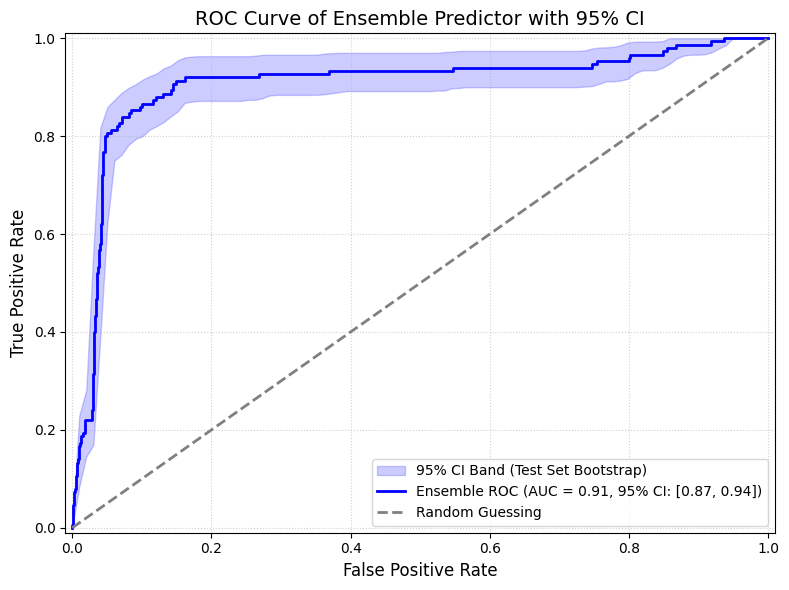

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample

ensemble_probs = np.mean(probs, axis=1)

main_fpr, main_tpr, _ = roc_curve(y_true, ensemble_probs)
main_auc = auc(main_fpr, main_tpr)

n_bootstraps = 500
boot_aucs = []
base_fpr = np.linspace(0, 1, 100)
tprs_interpolated = []

np.random.seed(42)

for i in range(n_bootstraps):
    indices = resample(np.arange(len(y_true)), replace=True)
    y_boot = y_true[indices]
    probs_boot = ensemble_probs[indices]

    if len(np.unique(y_boot)) < 2:
        continue

    fpr_i, tpr_i, _ = roc_curve(y_boot, probs_boot)
    boot_aucs.append(auc(fpr_i, tpr_i))

    tpr_interp = np.interp(base_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    tprs_interpolated.append(tpr_interp)

auc_lower = np.percentile(boot_aucs, 2.5)
auc_upper = np.percentile(boot_aucs, 97.5)

tprs_matrix = np.array(tprs_interpolated)
tpr_lower = np.percentile(tprs_matrix, 2.5, axis=0)
tpr_upper = np.percentile(tprs_matrix, 97.5, axis=0)
tpr_upper[-1] = 1.0

plt.figure(figsize=(8, 6))
plt.fill_between(base_fpr, tpr_lower, tpr_upper, color='blue', alpha=0.2,
                 label='95% CI Band (Test Set Bootstrap)')


plt.plot(main_fpr, main_tpr, color='blue', lw=2,
         label=f'Ensemble ROC (AUC = {main_auc:.2f}, 95% CI: [{auc_lower:.2f}, {auc_upper:.2f}])')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guessing')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve of Ensemble Predictor with 95% CI', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 2.b

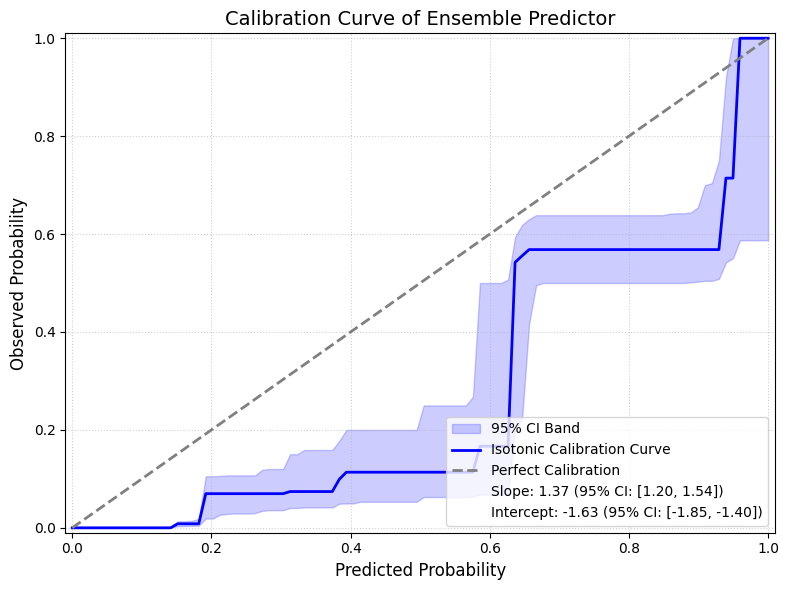

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
import warnings
warnings.filterwarnings('ignore')

ensemble_probs = np.array(ensemble_probs)

p_grid = np.linspace(0, 1, 100)

ir_main = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
ir_main.fit(ensemble_probs, y_true)
calib_main = ir_main.predict(p_grid)

eps = 1e-7

p_clipped_main = np.clip(ensemble_probs, eps, 1 - eps)
log_odds_main = np.log(p_clipped_main / (1 - p_clipped_main)).reshape(-1, 1)

log_reg_main = LogisticRegression(penalty=None)
log_reg_main.fit(log_odds_main, y_true)

slope_main = log_reg_main.coef_[0][0]
intercept_main = log_reg_main.intercept_[0]

n_bootstraps = 500
boot_curves = []
boot_slopes = []
boot_intercepts = []

np.random.seed(42)

for i in range(n_bootstraps):
    indices = resample(np.arange(len(y_true)), replace=True)
    y_boot = y_true[indices]
    p_boot = ensemble_probs[indices]

    if len(np.unique(y_boot)) < 2:
        continue

    ir = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    ir.fit(p_boot, y_boot)
    boot_curves.append(ir.predict(p_grid))

    p_clipped_boot = np.clip(p_boot, eps, 1 - eps)
    log_odds_boot = np.log(p_clipped_boot / (1 - p_clipped_boot)).reshape(-1, 1)

    log_reg_boot = LogisticRegression(penalty=None)
    log_reg_boot.fit(log_odds_boot, y_boot)

    boot_slopes.append(log_reg_boot.coef_[0][0])
    boot_intercepts.append(log_reg_boot.intercept_[0])

curves_matrix = np.array(boot_curves)
curve_lower = np.percentile(curves_matrix, 2.5, axis=0)
curve_upper = np.percentile(curves_matrix, 97.5, axis=0)

slope_lower = np.percentile(boot_slopes, 2.5)
slope_upper = np.percentile(boot_slopes, 97.5)

intercept_lower = np.percentile(boot_intercepts, 2.5)
intercept_upper = np.percentile(boot_intercepts, 97.5)

plt.figure(figsize=(8, 6))

plt.fill_between(p_grid, curve_lower, curve_upper, color='blue', alpha=0.2,
                 label='95% CI Band')

plt.plot(p_grid, calib_main, color='blue', lw=2,
         label='Isotonic Calibration Curve')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Perfect Calibration')

slope_text = f"Slope: {slope_main:.2f} (95% CI: [{slope_lower:.2f}, {slope_upper:.2f}])"
intercept_text = f"Intercept: {intercept_main:.2f} (95% CI: [{intercept_lower:.2f}, {intercept_upper:.2f}])"

plt.plot([], [], ' ', label=slope_text)
plt.plot([], [], ' ', label=intercept_text)

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Observed Probability', fontsize=12)
plt.title('Calibration Curve of Ensemble Predictor', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 2.c
The performance of discrimination is excellent, but the calibration is poor. It successfully distinguishes between STEMI and non-STEMI cases, meaning high-risk patients are consistently assigned higher scores than low-risk patients. However, the calibration curve reveals a severe systematic overestimation of STEMI risk. The curve lies significantly below the ideal line.

In conclusion, this model would be a helpful screening tool in an emergency room just to flag high-risk patients quickly. However, because it is so aggressive with its scoring, doctors definitely cannot trust the raw percentage outputs. The model would need to be recalibrated before anyone could actually use its probability numbers in real life.

# Q3
## 3.1

In [ ]:
from sklearn.metrics import confusion_matrix

fpr, tpr, thresholds = roc_curve(y_true, ensemble_probs)

spe = 1 - fpr
sen = tpr

def calculate_all_metrics(y_true, probs, threshold):
    y_pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    calc_sen = tp / (tp + fn) if (tp + fn) > 0 else 0
    calc_spe = tn / (tn + fp) if (tn + fp) > 0 else 0
    calc_ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    calc_npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    calc_f1 = 2 * (calc_ppv * calc_sen) / (calc_ppv + calc_sen) if (calc_ppv + calc_sen) > 0 else 0

    return threshold, calc_sen, calc_spe, calc_ppv, calc_npv, calc_f1

idx_high_sen = np.argmin(np.abs(sen - 0.98))
thresh_high_sen = thresholds[idx_high_sen]

t1, sen1, spe1, ppv1, npv1, f1_1 = calculate_all_metrics(y_true, ensemble_probs, thresh_high_sen)

print("--- Scenario 1: High Sensitivity (SEN ≈ 0.98) ---")
print(f"Probability Threshold : {t1:.2f}")
print(f"Sensitivity (SEN)     : {sen1:.2f}")
print(f"Specificity (SPE)     : {spe1:.2f}")
print(f"PPV (Precision)       : {ppv1:.2f}")
print(f"NPV                   : {npv1:.2f}")
print(f"F1 Score              : {f1_1:.2f}\n")


idx_high_spe = np.argmin(np.abs(spe - 0.98))
thresh_high_spe = thresholds[idx_high_spe]

t2, sen2, spe2, ppv2, npv2, f1_2 = calculate_all_metrics(y_true, ensemble_probs, thresh_high_spe)

print("--- Scenario 2: High Specificity (SPE ≈ 0.98) ---")
print(f"Probability Threshold : {t2:.2f}")
print(f"Sensitivity (SEN)     : {sen2:.2f}")
print(f"Specificity (SPE)     : {spe2:.2f}")
print(f"PPV (Precision)       : {ppv2:.2f}")
print(f"NPV                   : {npv2:.2f}")
print(f"F1 Score              : {f1_2:.2f}")

--- Scenario 1: High Sensitivity (SEN ≈ 0.98) ---
Probability Threshold : 0.15
Sensitivity (SEN)     : 0.98
Specificity (SPE)     : 0.15
PPV (Precision)       : 0.09
NPV                   : 0.99
F1 Score              : 0.16

--- Scenario 2: High Specificity (SPE ≈ 0.98) ---
Probability Threshold : 0.81
Sensitivity (SEN)     : 0.21
Specificity (SPE)     : 0.98
PPV (Precision)       : 0.48
NPV                   : 0.94
F1 Score              : 0.29


## 3.2

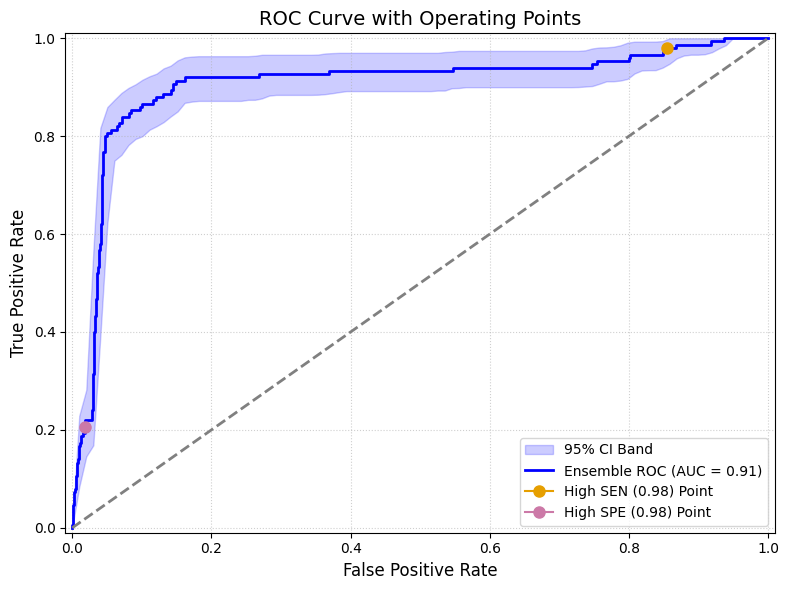

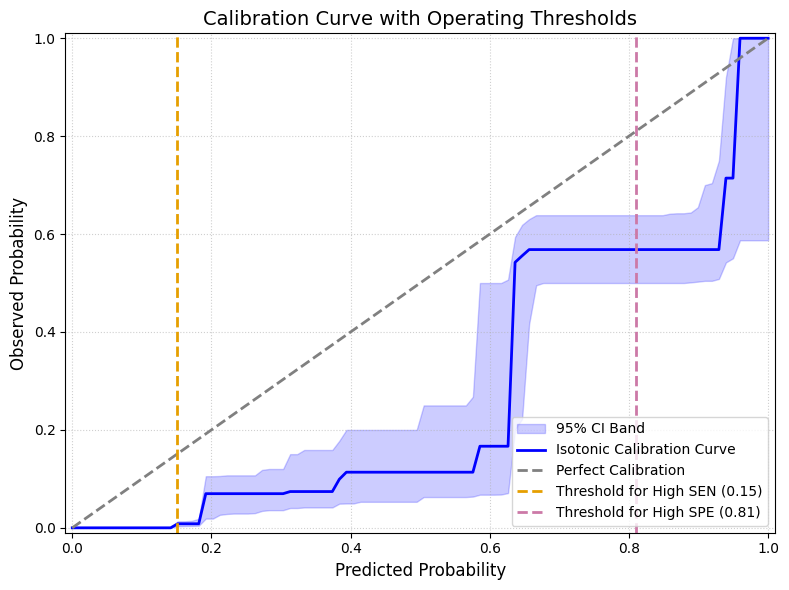

In [10]:
from sklearn.linear_model import LinearRegression

# 1. Load data and calculate metrics
df = pd.read_csv('pred.csv')
y_true = df['y'].values
probs = df.loc[:, 'prob_1':'prob_500'].values
ensemble_probs = np.array(np.mean(probs, axis=1))

main_fpr, main_tpr, thresholds = roc_curve(y_true, ensemble_probs)
main_auc = auc(main_fpr, main_tpr)

# Find operating points
idx_sen = np.argmin(np.abs(main_tpr - 0.98))
idx_spe = np.argmin(np.abs((1 - main_fpr) - 0.98))

# 2. Bootstrap for CI (can be skipped if variables are already in memory)
n_bootstraps = 500
base_fpr = np.linspace(0, 1, 100)
tprs_interpolated = []
np.random.seed(42)

for _ in range(n_bootstraps):
    indices = resample(np.arange(len(y_true)), replace=True)
    if len(np.unique(y_true[indices])) < 2: continue
    fpr_i, tpr_i, _ = roc_curve(y_true[indices], ensemble_probs[indices])
    tpr_interp = np.interp(base_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    tprs_interpolated.append(tpr_interp)

tpr_lower = np.percentile(tprs_interpolated, 2.5, axis=0)
tpr_upper = np.percentile(tprs_interpolated, 97.5, axis=0)

# 3. Plotting ROC
plt.figure(figsize=(8, 6))
plt.fill_between(base_fpr, tpr_lower, tpr_upper, color='blue', alpha=0.2, label='95% CI Band')
plt.plot(main_fpr, main_tpr, color='blue', lw=2, label=f'Ensemble ROC (AUC = {main_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

# Add Operating Points
plt.plot(main_fpr[idx_sen], main_tpr[idx_sen], marker='o', color='#E69F00', markersize=8,
         label=f'High SEN (0.98) Point')
plt.plot(main_fpr[idx_spe], main_tpr[idx_spe], marker='o', color='#CC79A7', markersize=8,
         label=f'High SPE (0.98) Point')

# Formatting
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve with Operating Points', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



# 1. Main Isotonic and Linear Regression
ir_main = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
ir_main.fit(ensemble_probs, y_true)
calib_main = ir_main.predict(p_grid)

lr_main = LinearRegression()
lr_main.fit(ensemble_probs.reshape(-1, 1), y_true)
slope_main, intercept_main = lr_main.coef_[0], lr_main.intercept_

# Thresholds from previous question
thresh_sen = thresholds[idx_sen]
thresh_spe = thresholds[idx_spe]

# 2. Bootstrap for CI
boot_curves = []
np.random.seed(42)

for _ in range(n_bootstraps):
    indices = resample(np.arange(len(y_true)), replace=True)
    if len(np.unique(y_true[indices])) < 2: continue
    ir = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    ir.fit(ensemble_probs[indices], y_true[indices])
    boot_curves.append(ir.predict(p_grid))

curve_lower = np.percentile(boot_curves, 2.5, axis=0)
curve_upper = np.percentile(boot_curves, 97.5, axis=0)

# 3. Plotting Calibration
plt.figure(figsize=(8, 6))
plt.fill_between(p_grid, curve_lower, curve_upper, color='blue', alpha=0.2, label='95% CI Band')
plt.plot(p_grid, calib_main, color='blue', lw=2, label='Isotonic Calibration Curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Perfect Calibration')

# Add Vertical Lines for Thresholds
plt.axvline(x=thresh_sen, color='#E69F00', linestyle='--', lw=2,
            label=f'Threshold for High SEN ({thresh_sen:.2f})')
plt.axvline(x=thresh_spe, color='#CC79A7', linestyle='--', lw=2,
            label=f'Threshold for High SPE ({thresh_spe:.2f})')

# Formatting
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Observed Probability', fontsize=12)
plt.title('Calibration Curve with Operating Thresholds', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 3.3
I would choose SEN = 0.98 operating point.

In a GP clinic, the primary goal when dealing with suspected STEMI is triage and screening. Since STEMI is a life-threatening emergency, the cost of a false negative is catastrophic. Therefore, we must prioritize catching as many true cases as possible.

At this operating point, the NPV is 0.99. This is valuable for a GP because it safely "rules out" the disease. If the algorithm scores below the threshold, the doctor can confidently reassure the patient and look for other causes of chest pain.

While the trade-off is a very low PPV (0.09) and high false-positive rate—meaning the GP will refer many healthy patients to the emergency room for further testing. This is completely acceptable in primary care. An unnecessary trip to the ER is a much safer mistake to make than missing a fatal heart attack. Conversely, the high specificity point (SPE=0.98) misses nearly 80% of actual STEMIs (SEN=0.21), which would be medical malpractice.

# Q4
## 4.1
I would display the following additional information alongside it:
- The 95% Confidence Interval for the patient: Since we have 500 bootstrap predictions for each patient, we should display the spread. This tells the doctor how "certain" or "uncertain" the ensemble model is about this exact individual.
- The Calibrated Probability: The raw mean probability severely overestimates the actual risk. I would display the calibrated probability so the GP sees the true statistical likelihood of a STEMI rather than an inflated number.
- A Categorical Action Alert based on the chosen threshold: Since we chose the 0.15 threshold to rule out STEMI, the system should display a warning like "High Risk: Exceeds 0.15 Threshold".
- Top Contributing Features: The model should give some top patient features (e.g. ECG abnormalities, age) that drove the probability score up or down, allowing the GP to cross-check the AI's logic with their own clinical judgment.
- Applicability Warning: Our model fails if a patient looks nothing like the training data. I would include an explicit warning flag (e.g., "Warning: Patient age and demographics fall outside the 95th percentile of the training distribution"). This tells the GP whether the model is actually qualified to evaluate this specific patient.